In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets, models
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import numpy as np
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/archive/'

Mounted at /content/drive


In [3]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Load base dataset
base_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

indices = list(range(len(base_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=base_dataset.targets, random_state=42)

train_dataset = Subset(base_dataset, train_idx)
val_dataset = Subset(base_dataset, val_idx)

print(f"Number of classes: {len(base_dataset.classes)}")
print(f"Classes: {base_dataset.classes}")

Number of classes: 15
Classes: ['s1', 's10', 's11', 's12', 's13', 's14', 's15', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9']


In [4]:
class TripletDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.labels = [dataset[i][1] for i in range(len(dataset))]
        self.label_to_indices = {label: np.where(np.array(self.labels) == label)[0]
                                 for label in set(self.labels)}

    def __getitem__(self, index):
        anchor_img, anchor_label = self.dataset[index]
        positive_index = index
        while positive_index == index:
            positive_index = np.random.choice(self.label_to_indices[anchor_label])
        negative_label = np.random.choice(list(set(self.labels) - {anchor_label}))
        negative_index = np.random.choice(self.label_to_indices[negative_label])

        positive_img = self.dataset[positive_index][0]
        negative_img = self.dataset[negative_index][0]
        return anchor_img, positive_img, negative_img

    def __len__(self):
        return len(self.dataset)

In [5]:
train_triplet_dataset = TripletDataset(train_dataset)
train_loader = DataLoader(train_triplet_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 128)
model = model.to(device)

# Loss and optimizer
criterion = nn.TripletMarginLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


In [6]:
def validate(model, val_loader):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for img, label in val_loader:
            img = img.to(device)
            emb = model(img).cpu().numpy()
            embeddings.append(emb[0])
            labels.append(label.item())

    embeddings = np.array(embeddings)
    labels = np.array(labels)

    correct = 0
    total = len(labels)

    for i in range(total):
        sims = cosine_similarity([embeddings[i]], embeddings)[0]
        sims[i] = -1
        nearest = np.argmax(sims)
        if labels[i] == labels[nearest]:
            correct += 1

    return correct / total

In [7]:
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for anchor, positive, negative in tqdm(train_loader):
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

        anchor_out = model(anchor)
        positive_out = model(positive)
        negative_out = model(negative)

        loss = criterion(anchor_out, positive_out, negative_out)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    val_acc = validate(model, val_loader)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

100%|██████████| 15/15 [00:38<00:00,  2.55s/it]


Epoch [1/5] | Loss: 0.1766 | Val Acc: 0.7667


100%|██████████| 15/15 [00:34<00:00,  2.27s/it]


Epoch [2/5] | Loss: 0.0631 | Val Acc: 1.0000


100%|██████████| 15/15 [00:35<00:00,  2.35s/it]


Epoch [3/5] | Loss: 0.0239 | Val Acc: 0.9667


100%|██████████| 15/15 [00:33<00:00,  2.26s/it]


Epoch [4/5] | Loss: 0.0393 | Val Acc: 0.9333


100%|██████████| 15/15 [00:35<00:00,  2.34s/it]


Epoch [5/5] | Loss: 0.0570 | Val Acc: 1.0000


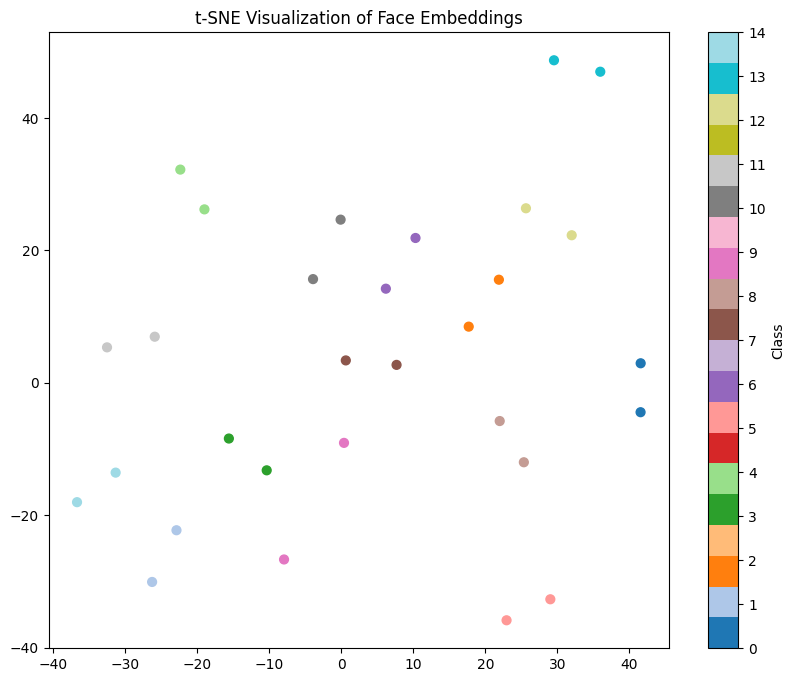

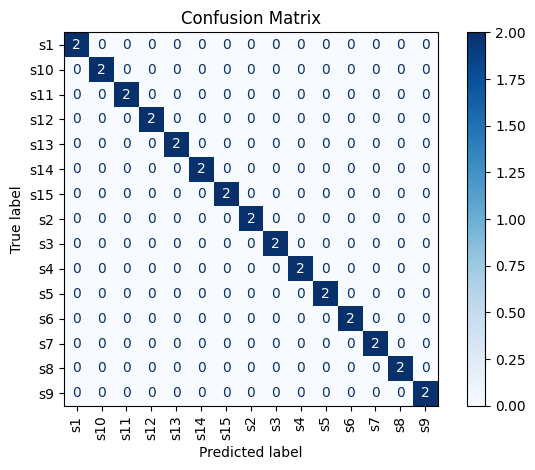

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import seaborn as sns

def validate_and_visualize(model, val_loader, class_names):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for img, label in val_loader:
            img = img.to(device)
            emb = model(img).cpu().numpy()
            embeddings.append(emb[0])
            labels.append(label.item())

    embeddings = np.array(embeddings)
    labels = np.array(labels)

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=10, random_state=42)
    tsne_results = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='tab20', s=40)
    plt.title('t-SNE Visualization of Face Embeddings')
    plt.colorbar(scatter, ticks=range(len(class_names)), label='Class')
    plt.show()

    # Confusion Matrix using nearest neighbor prediction
    y_pred = []
    for i in range(len(embeddings)):
        sims = cosine_similarity([embeddings[i]], embeddings)[0]
        sims[i] = -1  # exclude self
        nearest_idx = np.argmax(sims)
        y_pred.append(labels[nearest_idx])

    cm = confusion_matrix(labels, y_pred, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=90, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Accuracy
    acc = np.mean(np.array(y_pred) == np.array(labels))
    return acc

val_acc = validate_and_visualize(model, val_loader, base_dataset.classes)


In [9]:
from torchvision.io import read_image
from torchvision.transforms.functional import convert_image_dtype

def preprocess_image(image_path):
    image = Image.open(image_path).convert('L')  # grayscale
    image = image.convert('RGB')  # Convert to 3 channels
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])
    return transform(image).unsqueeze(0).to(device)  # shape: (1, 3, 128, 128)

def verify_faces(img_path1, img_path2, model, threshold=0.7):
    model.eval()
    img1 = preprocess_image(img_path1)
    img2 = preprocess_image(img_path2)

    with torch.no_grad():
        emb1 = model(img1)
        emb2 = model(img2)

    cosine_sim = F.cosine_similarity(emb1, emb2).item()
    same = cosine_sim > threshold
    print(f"Cosine Similarity: {cosine_sim:.4f} → {'Same person' if same else 'Different people'}")
    return same


In [11]:
img1 = '/content/drive/MyDrive/archive/s1/1.pgm'
img2 = '/content/drive/MyDrive/archive/s1/8.pgm'
img3 = '/content/drive/MyDrive/archive/s5/3.pgm'

verify_faces(img1, img2, model)  # likely: Same person
verify_faces(img1, img3, model)  # likely: Different people


Cosine Similarity: 0.8373 → Same person
Cosine Similarity: -0.0429 → Different people


False